---
title: Building Sentinel-3 Data Cubes with xcube EOPF Data Store
subtitle: Learn how to building analysis-ready data cubes from multiple EOPF Sentinel-3 Zarr samples.
authors:
  - name: Konstantin Ntokas
    orcid: 0000-0002-0049-0690
    github: konstntokas
    affiliations:
      - id: Brockmann Consult GmbH
        institution: Brockmann Consult GmbH
        ror: 04r0k9g65
reviewers:
  - name: Michele Claus
    orcid: 0000-0003-3680-381X
    github: clausmichele
    affiliations:
      - id: Eurac Research
        institution: Eurac Research
        ror: 01xt1w755
date: 2026-03-27
thumbnail: ../static/EOPF-on-bright-baseline.png
keywords: ["data access", "xarray", "EOPF Zarr products"]
tags: ["sentinel-3", "xcube", "land"]
releaseDate: 2026-03-27
datePublished: 2026-03-27
dateModified: 2026-03-27
github: https://github.com/EOPF-Sample-Service/eopf-sample-notebooks
license: Apache-2.0
---

```{image} ../static/EOPF-on-bright-baseline.png
:alt: ESA EOPF Zarr Logo
:width: 250px
:align: center
```

## Table of Contents
1. [Introduction](#Introduction_XCUBE_EOPF_SEN3)
2. [Main Features of the xcube-eopf Data Store for Sentinel-2](#Main_Features_XCUBE_EOPF_SEN3)
3. [Import modules](#Import_XCUBE_EOPF_SEN3)
4. [Access Sentinel-3 ARDC](#Access_XCUBE_EOPF_SEN3)
5. [Conclusion](#Conclusion_XCUBE_EOPF_SEN3)

(Introduction_XCUBE_EOPF_SEN2)=
## Introduction


`xcube-eopf` is a Python package that extends [xcube](https://xcube.readthedocs.io/en/latest) with a new [data store](https://xcube.readthedocs.io/en/latest/dataaccess.html#available-data-stores) called `"eopf-zarr"`. This plugin enables the creation of analysis-ready data cubes (ARDC) from multiple Sentinel products published by the [EOPF Sentinel Zarr Sample Service](https://zarr.eopf.copernicus.eu/).

In this notebook, we demonstrate how to use the **xcube EOPF data store** to access multiple **Sentinel-3** EOPF Zarr products and generate 3D analysis-ready data cubes (ARDC).

For a general introduction to the xcube EOPF Data Store, see the [introduction notebook](https://eopf-sample-service.github.io/xcube-eopf/examples/introduction/).  

- 🐙 **GitHub:** [EOPF Sample Service – xcube-eopf](https://github.com/EOPF-Sample-Service/xcube-eopf)  
- ❗ **Issue Tracker:** [Submit or view issues](https://github.com/EOPF-Sample-Service/xcube-eopf/issues)  
- 📘 **Documentation:** [xarray-eopf Docs](https://eopf-sample-service.github.io/xcube-eopf/)

:::{hint} Overview
**Questions**
- How can the xcube-eopf data store be used to access Sentinel-3 products?
- What are the key features of the xcube-eopf data store for working with Sentinel-3 data?

**Objectives**
- Learn how to open and combine multiple EOPF Sentinel-3 Zarr datasets into analysis-ready data cubes (ARDCs).
- Understand the core features and capabilities of the xcube EOPF data store for Sentinel-3 workflows.
:::

---

(Main_Features_XCUBE_EOPF_SEN3)=
## Main Features of the xcube-eopf Data Store for Sentinel-3

Sentinel-3 has two instruments on board: 

🌊 **OLCI — Ocean and Land Colour Instrument**

- **Purpose**: Primarily designed for ocean and land surface monitoring.
- **Spectral bands**: 21 bands (400–1020 nm).
- **Spatial resolution**: 300 m.
- **Swath width**: ~1,270 km

🔥 **SLSTR — Sea and Land Surface Temperature Radiometer**

- **Purpose**: Measures global sea and land surface temperatures with high accuracy.
- **Spectral bands**: 9 bands (visible to thermal infrared, 0.55–12 μm).
- **Spatial resolution**: 500 m (visible & shortwave infrared bands) and 1 km 
  (thermal infrared bands).
- **Swath width**: ~1,400 km

Sentinel-3 data products are distributed as **STAC Items**, where each item 
corresponds to a single tile. The datasets are provided in their 
**native 2D irregular grid** and typically require rectification for analysis-ready 
applications. 

**Data Cube Generation Workflow**

The workflow for building 3D analysis-ready cubes from Sentinel-3 products involves 
the following steps:

1. **Query** tiles using the [EOPF Zarr Sample Service STAC API](https://stac.core.eopf.eodc.eu/) for a given time range and 
   spatial extent.
2. **Group** items by solar day and orbit direction (ascending and descending passes).
3. **Rectify** data from the native 2D irregular grid to a regular grid using 
   [xcube-resampling](https://xcube-dev.github.io/xcube-resampling/guide/#3-rectification).
4. **Mosaic** adjacent tiles into seamless daily scenes.
5. **Stack** the daily mosaics along the temporal axis to form 3D data cubes 
   for each variable (e.g., spectral bands).

> **Note:** Rectification (irregular → regular grid) is computationally expensive and may slow down cube generation.  

📚 **More info:** [xcube-eopf Sentinel-3 Documentation](https://eopf-sample-service.github.io/xcube-eopf/guide/#sentinel-3)

---

(Import_XCUBE_EOPF_SEN3)=
## Import Modules

The `xcube-eopf` data store is provided as a plugin for `xcube`. Once installed, it registers automatically, allowing you to import `xcube` just like any other [xcube data store](https://xcube.readthedocs.io/en/latest/dataaccess.html#data-access):

In [1]:
import datetime
import matplotlib.pyplot as plt
from xcube.core.store import new_data_store
from xcube_resampling.utils import reproject_bbox

(Access_XCUBE_EOPF_SEN3)=
## Access Sentinel-3 ARDC

In this section, we demonstrate the available features and options for opening and generating spatio-temporal data cubes from multiple Sentinel-3 products.  
To initialize an `eopf-zarr` data store, run the cell below:

In [2]:
store = new_data_store("eopf-zarr")

The data IDs refer to STAC collections available via the [STAC Browser](https://stac.browser.user.eopf.eodc.eu). The following cell demonstrates how to list the available data IDs.

For Sentinel-3, the following STAC collections are currently accessible through xcube-eopf:

| Data ID                   | Description                                                           |
|---------------------------|-----------------------------------------------------------------------|
| ["sentinel-3-olci-l1-efr"](https://stac.browser.user.eopf.eodc.eu/collections/sentinel-3-olci-l1-efr)  | Level-1 full-resolution top-of-atmosphere radiances from OLCI         |
| ["sentinel-3-olci-l2-lfr"](https://stac.browser.user.eopf.eodc.eu/collections/sentinel-3-olci-l2-lfr)  | Level-2 land and atmospheric geophysical parameters derived from OLCI |
| ["sentinel-3-slstr-l1-rbt"](https://stac.browser.user.eopf.eodc.eu/collections/sentinel-3-slstr-l1-rbt) | Level-1 radiances and brightness temperatures from SLSTR              |
| ["sentinel-3-slstr-l2-lst"](https://stac.browser.user.eopf.eodc.eu/collections/sentinel-3-slstr-l2-lst) | Level-2 land surface temperature products from SLSTR                  |

In [3]:
store.list_data_ids()

['sentinel-2-l1c',
 'sentinel-2-l2a',
 'sentinel-3-olci-l1-efr',
 'sentinel-3-olci-l2-lfr',
 'sentinel-3-slstr-l1-rbt',
 'sentinel-3-slstr-l2-lst']

### Access Sentinel-3 OLCI L1 EFR ARDC

Below, you can explore the parameters of the `open_data()` method for each supported data product. The following cell generates a JSON schema listing all available opening parameters for Sentinel-3 OLCI L1 EFR products.

In [4]:
store.get_open_data_params_schema(data_id="sentinel-3-olci-l1-efr")

Next, we generate a data cube by setting the `data_id` to `"sentinel-3-olci-l1-efr"`. The spatial extent is defined using a bounding box over Southern Italy, while the temporal range is restricted to the last two days. The coordinate reference system (CRS) is set to WGS84 (EPSG:4326) by default.

In [5]:
bbox = [14.0, 37.0, 18.0, 41.0]
time_range = [str(datetime.date.today() - datetime.timedelta(days=2)), None]
resolution = 300  # meter
variables = ["oa02_radiance", "oa04_radiance", "oa06_radiance"]  # RGB bands

In [6]:
ds = store.open_data(
    data_id="sentinel-3-olci-l1-efr",
    bbox=bbox,
    time_range=time_range,
    spatial_res=resolution / 111320,  # conversion to degree approx.
    variables=variables,
)
ds

<xarray.Dataset> Size: 106MB
Dimensions:        (time: 2, lat: 1485, lon: 1485)
Coordinates:
  * time           (time) datetime64[s] 16B 2026-03-30T09:22:42 2026-03-31T09...
  * lat            (lat) float64 12kB 41.0 41.0 41.0 40.99 ... 37.01 37.0 37.0
  * lon            (lon) float64 12kB 14.0 14.0 14.01 14.01 ... 18.0 18.0 18.0
    spatial_ref    int64 8B 0
Data variables:
    oa02_radiance  (time, lat, lon) float64 35MB dask.array<chunksize=(1, 1485, 1485), meta=np.ndarray>
    oa04_radiance  (time, lat, lon) float64 35MB dask.array<chunksize=(1, 1485, 1485), meta=np.ndarray>
    oa06_radiance  (time, lat, lon) float64 35MB dask.array<chunksize=(1, 1485, 1485), meta=np.ndarray>
Attributes: (13)

Note that the 3D datacube generation is fully **lazy**. Actual data download and processing (e.g., mosaicking, stacking) are performed **on demand** and are only triggered when the data is written or visualized.  

As an example, the next cell plots a single timestamp of the red band (`oa06_radiance`).

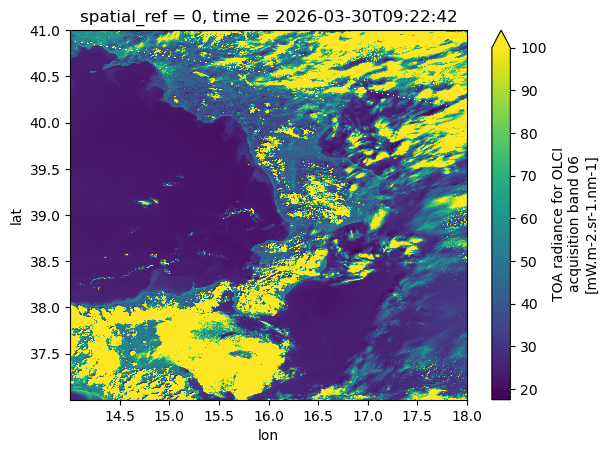

In [7]:
ds.oa06_radiance.isel(time=0).plot(vmax=100)

We can also request the same data cube in a different coordinate reference system (CRS), such as UTM. The xcube-eopf framework supports on-the-fly reprojection to any user-defined CRS.

Resampling behavior can be customized if needed. By default, bilinear interpolation is applied to floating-point data, while nearest-neighbor interpolation is used for integer data. For aggregation, float arrays use averaging, and integer arrays use a center-based approach. (see [xcube-resampling docuementation](https://xcube-dev.github.io/xcube-resampling/guide/#common-parameters-for-all-resampling-algorithms))

If the requested spatial resolution is coarser than the native resolution, the data are first aggregated and then reprojected, with interpolation applied during the reprojection step.

In [8]:
crs_utm = "EPSG:32632"
bbox_utm = reproject_bbox(bbox, "EPSG:4326", crs_utm)

In [9]:
ds = store.open_data(
    data_id="sentinel-3-olci-l1-efr",
    bbox=bbox_utm,
    time_range=time_range,
    spatial_res=resolution,
    variables=variables,
    crs=crs_utm,
    interp_methods="nearest",
    agg_methods="center",
)
ds

<xarray.Dataset> Size: 96MB
Dimensions:        (time: 2, y: 1572, x: 1271)
Coordinates:
  * time           (time) datetime64[s] 16B 2026-03-30T09:22:42 2026-03-31T09...
  * y              (y) float64 13kB 4.578e+06 4.578e+06 ... 4.107e+06 4.107e+06
  * x              (x) float64 10kB 9.207e+05 9.21e+05 ... 1.301e+06 1.302e+06
    spatial_ref    int64 8B 0
Data variables:
    oa02_radiance  (time, y, x) float64 32MB dask.array<chunksize=(1, 1572, 1271), meta=np.ndarray>
    oa04_radiance  (time, y, x) float64 32MB dask.array<chunksize=(1, 1572, 1271), meta=np.ndarray>
    oa06_radiance  (time, y, x) float64 32MB dask.array<chunksize=(1, 1572, 1271), meta=np.ndarray>
Attributes: (13)

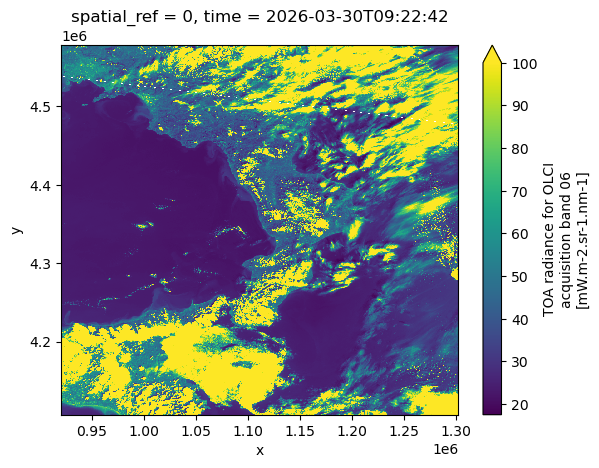

In [10]:
ds.oa06_radiance.isel(time=0).plot(vmax=100)

### Access Sentinel-3 OLCI Level-2 LFR ARDC

We now want to generate a similar data cube from the Sentinel-3 OLCI Level-2 LFR product. We therefore assign `data_id` to `"sentinel-3-olci-l2-lfr"`.

In [11]:
ds = store.open_data(
    data_id="sentinel-3-olci-l2-lfr",
    bbox=bbox,
    time_range=time_range,
    spatial_res=resolution / 111320,  # conversion to degree approx.
)
ds

<xarray.Dataset> Size: 176MB
Dimensions:      (time: 2, lat: 1485, lon: 1485)
Coordinates:
  * time         (time) datetime64[s] 16B 2026-03-30T09:22:42 2026-03-31T09:2...
  * lat          (lat) float64 12kB 41.0 41.0 41.0 40.99 ... 37.01 37.0 37.0
  * lon          (lon) float64 12kB 14.0 14.0 14.01 14.01 ... 18.0 18.0 18.0
    spatial_ref  int64 8B 0
Data variables:
    gifapar      (time, lat, lon) float64 35MB dask.array<chunksize=(1, 1485, 1485), meta=np.ndarray>
    iwv          (time, lat, lon) float64 35MB dask.array<chunksize=(1, 1485, 1485), meta=np.ndarray>
    otci         (time, lat, lon) float64 35MB dask.array<chunksize=(1, 1485, 1485), meta=np.ndarray>
    rc681        (time, lat, lon) float64 35MB dask.array<chunksize=(1, 1485, 1485), meta=np.ndarray>
    rc865        (time, lat, lon) float64 35MB dask.array<chunksize=(1, 1485, 1485), meta=np.ndarray>
Attributes: (14)

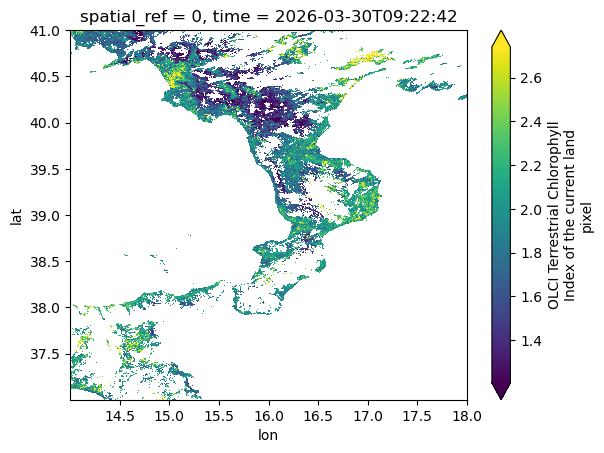

In [12]:
ds.otci.isel(time=0).plot(robust=True)

### Access Sentinel-3 SLSTR Level-2 LST 

Next, we want to generate a similar data cube from the Sentinel-3 SLSTR Level-2 LST product. We therefore assign `data_id` to `"sentinel-3-slstr-l2-lst"`.

For SLSTR products, a terrain correction is applied during this process. This is
necessary because the original geolocation is corrected only for Earth curvature,
but not for terrain variability caused by topography. See the
[SLSTR product description](https://sentiwiki.copernicus.eu/web/slstr-products)
for details.

In [13]:
ds = store.open_data(
    data_id="sentinel-3-slstr-l2-lst",
    bbox=bbox,
    time_range=time_range,
    spatial_res=resolution / 111320,  # conversion to degree approx.
)
ds

<xarray.Dataset> Size: 71MB
Dimensions:      (time: 4, lat: 1485, lon: 1485)
Coordinates:
  * time         (time) datetime64[s] 32B 2026-03-30T09:22:42 ... 2026-03-31T...
  * lat          (lat) float64 12kB 41.0 41.0 41.0 40.99 ... 37.01 37.0 37.0
  * lon          (lon) float64 12kB 14.0 14.0 14.01 14.01 ... 18.0 18.0 18.0
    spatial_ref  int64 8B 0
Data variables:
    lst          (time, lat, lon) float64 71MB dask.array<chunksize=(1, 1485, 1485), meta=np.ndarray>
Attributes: (20)

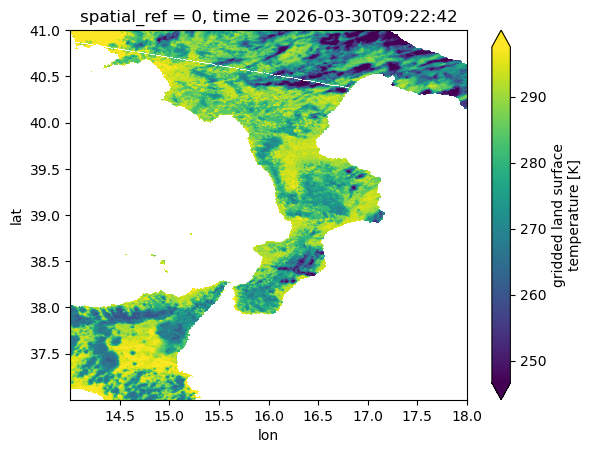

In [14]:
ds.lst.isel(time=0).plot(robust=True)

### Access Sentinel-3 SLSTR Level-1B RBT

Lastly, we generate a similar data cube from the Sentinel-3 SLSTR Level-1B RBT product by setting `data_id` to `"sentinel-3-slstr-l1-rbt"`.

The SLSTR instrument provides observations from two viewing geometries: **nadir** and **oblique** (forward view). These are designed to improve atmospheric correction and enable more accurate surface measurements.

Accordingly, many variables in the RBT product are available in pairs:
- `*_an` → **nadir view** (e.g. `s1_radiance_an`)
- `*_ao` → **oblique view** (e.g. `s1_radiance_ao`)

In the next example, we request both views for the S1 thermal channel. 

In [15]:
ds = store.open_data(
    data_id="sentinel-3-slstr-l1-rbt",
    bbox=bbox,
    time_range=time_range,
    spatial_res=resolution / 111320,  # conversion to degree approx.
    variables=["s1_radiance_an", "s1_radiance_ao"],
)
ds

<xarray.Dataset> Size: 141MB
Dimensions:         (time: 4, lat: 1485, lon: 1485)
Coordinates:
  * time            (time) datetime64[s] 32B 2026-03-30T09:22:42 ... 2026-03-...
  * lat             (lat) float64 12kB 41.0 41.0 41.0 40.99 ... 37.01 37.0 37.0
  * lon             (lon) float64 12kB 14.0 14.0 14.01 14.01 ... 18.0 18.0 18.0
    spatial_ref     int64 8B 0
Data variables:
    s1_radiance_an  (time, lat, lon) float64 71MB dask.array<chunksize=(1, 1485, 1485), meta=np.ndarray>
    s1_radiance_ao  (time, lat, lon) float64 71MB dask.array<chunksize=(1, 1485, 1485), meta=np.ndarray>
Attributes: (94)

As an example, we plot the nadir and oblique views of the S1 thermal channel side by side.

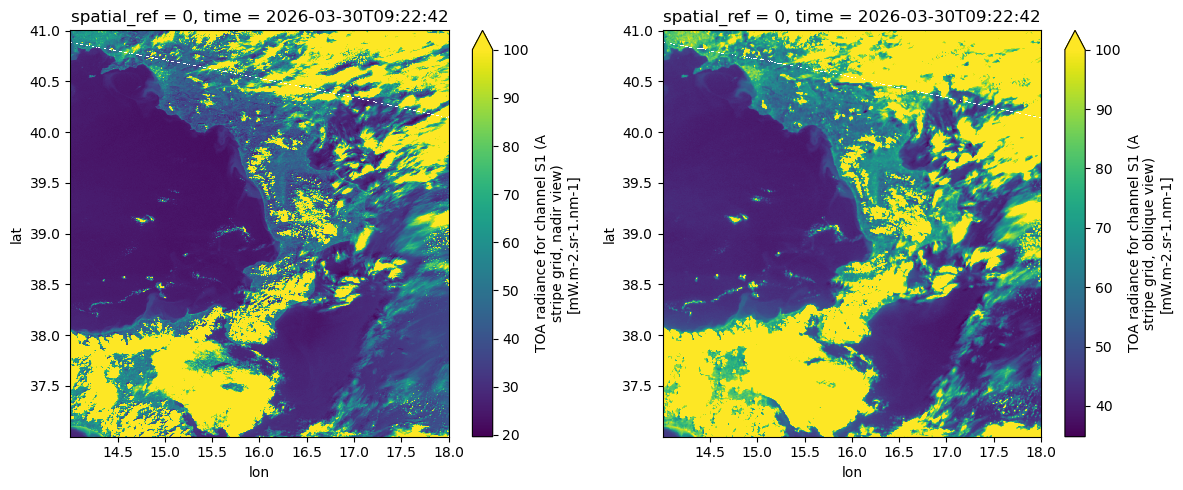

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ds.s1_radiance_an.isel(time=0).plot(ax=ax[0], vmax=100)
ds.s1_radiance_ao.isel(time=0).plot(ax=ax[1], vmax=100)
plt.tight_layout()

---

(Conclusion_XCUBE_EOPF_SEN3)=
## Conclusion

This notebook highlighted the main features of the **xcube EOPF Data Store** for Sentinel-3, which enables seamless access to multiple EOPF Zarr products as **analysis-ready data cubes (ARDCs)**. 

Key takeaways:

- **3D spatio-temporal data cubes** can be generated from multiple EOPF Sentinel Zarr samples.  
- Supports access to **Sentinel-3 OLCI L1 EFR**, **Sentinel-3 OLCI Level-2 LFR**, **Sentinel-3 SLSTR Level-2 LST**, and **Sentinel-3 SLSTR Level-1B RBT** collections.  
- Data cubes can be requested with any **CRS**, spatial extent, temporal range, and spatial resolution.

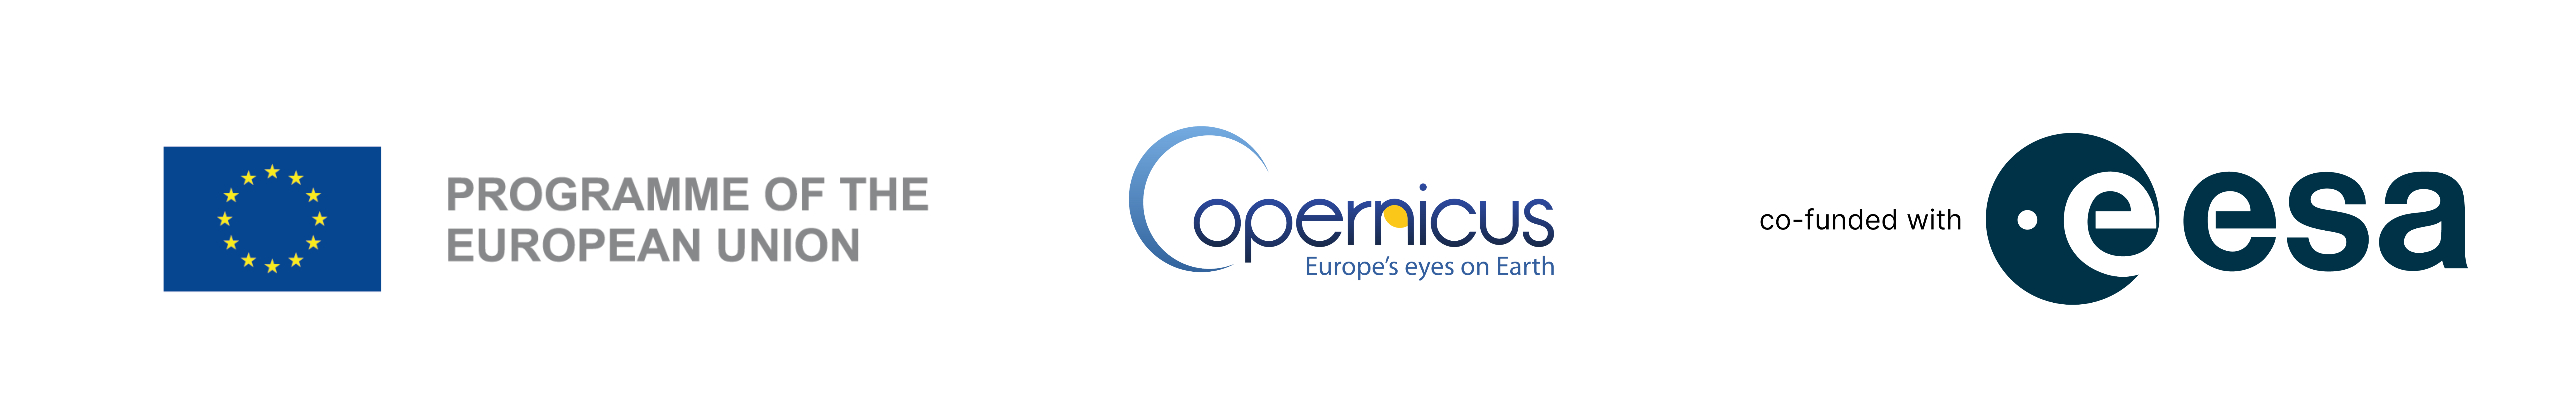